In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")
SEED = 42

cancer = fetch_ucirepo(id=17)
X = cancer.data.features.copy()
X = X.drop(columns=["ID"], errors="ignore")
y = cancer.data.targets.squeeze().map({"B": 0, "M": 1})

print(X.shape)
print(y.value_counts())
print("Nulos:", int(X.isna().sum().sum()))
display(X.head())

(569, 30)
Diagnosis
0    357
1    212
Name: count, dtype: int64
Nulos: 0


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
display(X.describe().T[["mean", "std", "min", "max"]].round(3))

,mean,std,min,max
radius1,14.127,3.524,6.981,28.110
texture1,19.290,4.301,9.710,39.280
perimeter1,91.969,24.299,43.790,188.500
area1,654.889,351.914,143.500,2501.000
smoothness1,0.096,0.014,0.053,0.163
compactness1,0.104,0.053,0.019,0.345
concavity1,0.089,0.080,0.000,0.427
concave_points1,0.049,0.039,0.000,0.201
symmetry1,0.181,0.027,0.106,0.304
fractal_dimension1,0.063,0.007,0.050,0.097


In [5]:
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED
)

for nombre, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{nombre}: {len(yy)} casos | % malignos: {100 * yy.mean():.1f}")

train: 341 casos | % malignos: 37.2
val: 114 casos | % malignos: 37.7
test: 114 casos | % malignos: 36.8


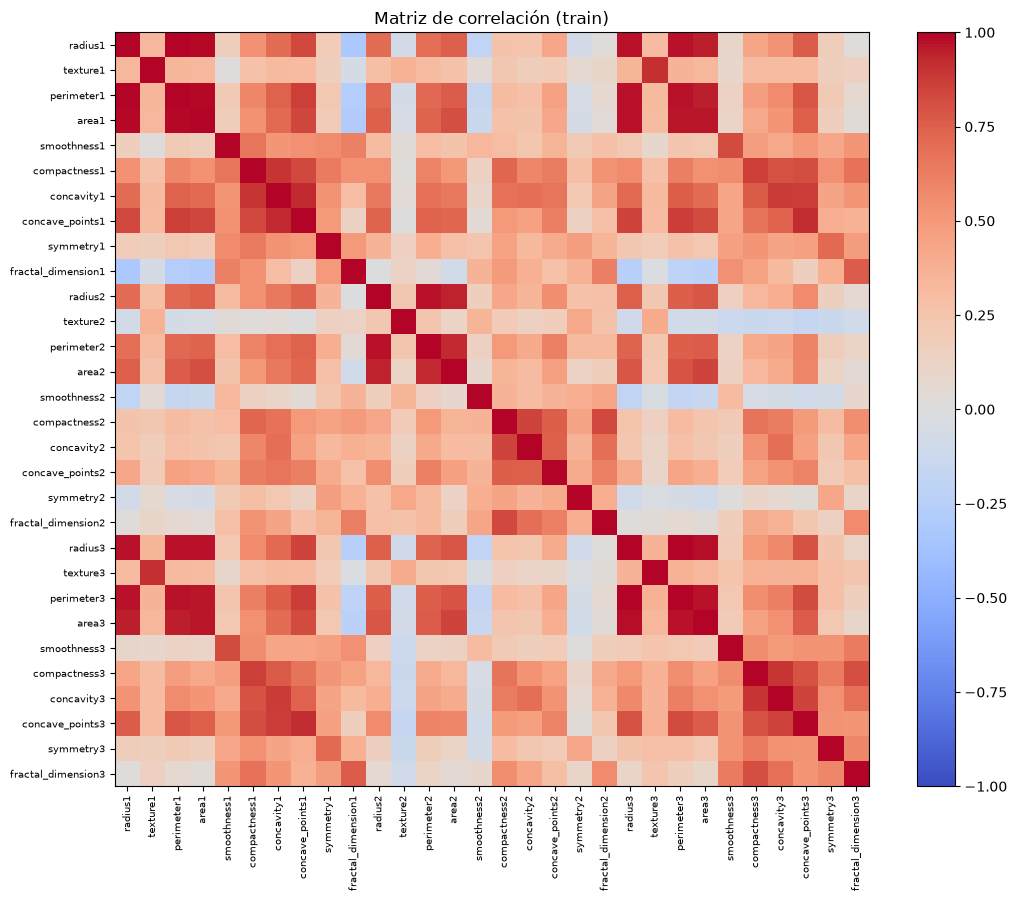

In [6]:
corr_mat = X_train.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_mat, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_mat))); ax.set_xticklabels(corr_mat.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr_mat))); ax.set_yticklabels(corr_mat.columns, fontsize=7)
plt.colorbar(im); ax.set_title("Matriz de correlación (train)")
plt.tight_layout(); plt.show()

In [7]:
pares = (corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
         .stack().rename("corr").reset_index())
pares.columns = ["var_a", "var_b", "corr"]
pares = pares[pares["corr"].abs() > 0.9].sort_values("corr", key=np.abs, ascending=False)

print("Pares con |r| > 0.9:", len(pares))
print(pares.head(20).to_string())

Pares con |r| > 0.9: 21
               var_a            var_b      corr
2            radius1       perimeter1  0.997831
622          radius3       perimeter3  0.993829
3            radius1            area1  0.987064
63        perimeter1            area1  0.986496
623          radius3            area3  0.982267
683       perimeter3            area3  0.976554
82        perimeter1       perimeter3  0.975609
20           radius1          radius3  0.974526
80        perimeter1          radius3  0.974286
22           radius1       perimeter3  0.970396
110            area1          radius3  0.970009
312          radius2       perimeter2  0.969638
113            area1            area3  0.968689
112            area1       perimeter3  0.966845
83        perimeter1            area3  0.945949
23           radius1            area3  0.945375
313          radius2            area2  0.944875
187       concavity1  concave_points1  0.923606
373       perimeter2            area2  0.923434
237  concave_poi

In [8]:
for sufijo in ["1", "2", "3"]:
    cols = [f"radius{sufijo}", f"perimeter{sufijo}", f"area{sufijo}"]
    print(f"\nResumen {sufijo}")
    print(X_train[cols].corr().round(3).to_string())


Resumen 1
            radius1  perimeter1  area1
radius1       1.000       0.998  0.987
perimeter1    0.998       1.000  0.986
area1         0.987       0.986  1.000

Resumen 2
            radius2  perimeter2  area2
radius2       1.000       0.970  0.945
perimeter2    0.970       1.000  0.923
area2         0.945       0.923  1.000

Resumen 3
            radius3  perimeter3  area3
radius3       1.000       0.994  0.982
perimeter3    0.994       1.000  0.977
area3         0.982       0.977  1.000


In [16]:
# Redundancia entre los tres resúmenes de cada medida (1 = media, 2 = error estándar, 3 = peor valor)
medidas = ["radius", "texture", "perimeter", "area", "smoothness",
           "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"]
filas = []
for m in medidas:
    c = X_train[[f"{m}1", f"{m}2", f"{m}3"]].corr()
    filas.append({"medida": m, "r(1,2)": c.iloc[0, 1], "r(1,3)": c.iloc[0, 2], "r(2,3)": c.iloc[1, 2]})
display(pd.DataFrame(filas).set_index("medida").round(3))

# Textura: ¿con qué otras variables se correlaciona más?
for t in ["texture1", "texture2", "texture3"]:
    print(f"\n{t}: mayores |r| con otras variables")
    print(corr_mat[t].drop(t).abs().sort_values(ascending=False).head(3).round(3).to_string())

,"r(1,2)","r(1,3)","r(2,3)"
medida,,,
radius,0.698,0.975,0.747
texture,0.373,0.910,0.399
perimeter,0.711,0.976,0.755
area,0.810,0.969,0.851
smoothness,0.332,0.827,0.305
compactness,0.726,0.865,0.664
concavity,0.691,0.879,0.694
concave_points,0.622,0.915,0.609
symmetry,0.470,0.705,0.426



texture1: mayores |r| con otras variables
texture3      0.910
texture2      0.373
perimeter3    0.357

texture2: mayores |r| con otras variables
symmetry2    0.420
texture3     0.399
texture1     0.373

texture3: mayores |r| con otras variables
texture1      0.910
texture2      0.399
perimeter3    0.365


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, mutual_info_classif

sc = StandardScaler().fit(X_train)
Xs_train = pd.DataFrame(sc.transform(X_train), columns=X.columns, index=X_train.index)

ranking = pd.DataFrame(index=X.columns)

F, p = f_classif(Xs_train, y_train)
ranking["anova_F"] = F
ranking["mutual_info"] = mutual_info_classif(Xs_train, y_train, random_state=SEED)

print(ranking.sort_values("anova_F", ascending=False).round(3).to_string())

                    anova_F  mutual_info
concave_points3     575.592        0.436
perimeter3          539.160        0.448
concave_points1     533.037        0.456
radius3             517.155        0.457
perimeter1          429.967        0.415
radius1             402.343        0.381
area3               386.711        0.449
area1               353.575        0.375
concavity1          325.497        0.347
concavity3          230.803        0.290
compactness1        196.658        0.235
compactness3        180.426        0.247
radius2             171.177        0.225
perimeter2          165.791        0.256
area2               153.982        0.345
texture3            104.504        0.158
symmetry3            81.519        0.093
concave_points2      81.451        0.140
texture1             77.472        0.098
smoothness3          65.529        0.090
symmetry1            54.642        0.118
smoothness1          49.965        0.055
fractal_dimension3   37.356        0.071
compactness2    

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# --- L1: ¿cuántas variables sobreviven según la penalización? ---
for C in [0.05, 0.1, 0.2, 0.5, 1.0]:
    m = LogisticRegression(penalty="l1", solver="liblinear", C=C, random_state=SEED).fit(Xs_train, y_train)
    print(f"C = {C}: variables con coef != 0: {int((m.coef_[0] != 0).sum())}")

l1 = LogisticRegression(penalty="l1", solver="liblinear", C=0.2, random_state=SEED).fit(Xs_train, y_train)
ranking["l1_abs_coef"] = np.abs(l1.coef_[0])

# --- RFE: eliminación recursiva hasta quedar con 10 ---
rfe = RFE(LogisticRegression(max_iter=2000), n_features_to_select=10).fit(Xs_train, y_train)
ranking["rfe_posicion"] = rfe.ranking_

print("\nL1 (C=0.2), variables seleccionadas:")
print(ranking.loc[ranking["l1_abs_coef"] > 0, "l1_abs_coef"].sort_values(ascending=False).round(3).to_string())
print("\nRFE, las 10 que quedaron:", list(ranking.index[ranking["rfe_posicion"] == 1]))

C = 0.05: variables con coef != 0: 5
C = 0.1: variables con coef != 0: 6
C = 0.2: variables con coef != 0: 7
C = 0.5: variables con coef != 0: 9
C = 1.0: variables con coef != 0: 14

L1 (C=0.2), variables seleccionadas:
radius3            1.972
concave_points1    1.836
texture3           1.003
area3              0.624
symmetry3          0.346
smoothness3        0.257
concave_points3    0.046

RFE, las 10 que quedaron: ['radius1', 'concavity1', 'concave_points1', 'radius2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3']


In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, recall_score, f1_score

def make_rna(seed=SEED):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                              max_iter=1000, random_state=seed))
    ])

rna_tmp = make_rna().fit(X_train, y_train)
pv = rna_tmp.predict(X_val)
print(f"Validación con 30 vars -> accuracy {accuracy_score(y_val, pv):.3f}, "
      f"recall {recall_score(y_val, pv):.3f}, F1 {f1_score(y_val, pv):.3f}")

perm = permutation_importance(rna_tmp, X_val, y_val, n_repeats=20,
                              scoring="f1", random_state=SEED)
ranking["perm_importance"] = perm.importances_mean
print(ranking["perm_importance"].sort_values(ascending=False).round(4).to_string())

Validación con 30 vars -> accuracy 0.965, recall 0.977, F1 0.955
area2                 0.0225
fractal_dimension2    0.0163
radius2               0.0148
perimeter2            0.0137
smoothness3           0.0132
texture1              0.0127
texture3              0.0122
fractal_dimension1    0.0109
perimeter3            0.0106
area3                 0.0101
radius3               0.0095
concavity1            0.0072
perimeter1            0.0063
concavity3            0.0062
concavity2            0.0059
compactness2          0.0058
smoothness1           0.0045
symmetry3             0.0043
area1                 0.0037
fractal_dimension3    0.0032
radius1               0.0031
concave_points1       0.0020
concave_points3       0.0004
texture2             -0.0001
concave_points2      -0.0001
smoothness2          -0.0017
compactness1         -0.0022
compactness3         -0.0044
symmetry2            -0.0088
symmetry1            -0.0105


In [12]:
rng = np.random.RandomState(SEED)
B = 50
cols = X.columns
f_anova = pd.Series(0, index=cols, dtype=int)
f_l1 = pd.Series(0, index=cols, dtype=int)
f_rfe = pd.Series(0, index=cols, dtype=int)

for _ in range(B):
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    Xb, yb = X_train.iloc[idx], y_train.iloc[idx]
    Xbs = StandardScaler().fit_transform(Xb)

    Fb, _ = f_classif(Xbs, yb)
    f_anova[pd.Series(Fb, index=cols).nlargest(10).index] += 1

    l1b = LogisticRegression(penalty="l1", solver="liblinear", C=0.2, random_state=SEED).fit(Xbs, yb)
    f_l1[cols[l1b.coef_[0] != 0]] += 1

    rfeb = RFE(LogisticRegression(max_iter=2000), n_features_to_select=10).fit(Xbs, yb)
    f_rfe[cols[rfeb.support_]] += 1

estab = pd.DataFrame({"ANOVA_top10": f_anova / B, "L1": f_l1 / B, "RFE_10": f_rfe / B})
estab["media"] = estab.mean(axis=1)
print(estab.sort_values("media", ascending=False).round(2).to_string())

                    ANOVA_top10    L1  RFE_10  media
concave_points1            1.00  1.00    0.96   0.99
radius3                    1.00  0.84    0.98   0.94
area3                      1.00  0.50    0.98   0.83
perimeter3                 1.00  0.32    0.84   0.72
concave_points3            1.00  0.54    0.56   0.70
texture3                   0.00  1.00    1.00   0.67
concavity1                 1.00  0.08    0.50   0.53
radius1                    1.00  0.04    0.36   0.47
smoothness3                0.00  0.78    0.56   0.45
area1                      1.00  0.00    0.32   0.44
symmetry3                  0.00  0.98    0.28   0.42
perimeter1                 1.00  0.00    0.24   0.41
radius2                    0.06  0.30    0.62   0.33
area2                      0.28  0.06    0.62   0.32
concavity3                 0.50  0.20    0.26   0.32
fractal_dimension2         0.00  0.32    0.34   0.22
compactness2               0.00  0.00    0.20   0.07
compactness1               0.16  0.00    0.02 

In [13]:
def poda_redundancia(orden, corr_mat, umbral=0.9, k=10):
    elegidas = []
    for v in orden:
        if all(abs(corr_mat.loc[v, e]) <= umbral for e in elegidas):
            elegidas.append(v)
        if len(elegidas) == k:
            break
    return elegidas

estab_media = estab["media"].sort_values(ascending=False)

candidatos = {
    "Todas": list(X.columns),
    "A_anova_poda": poda_redundancia(ranking["anova_F"].sort_values(ascending=False).index, corr_mat, 0.9, 10),
    "B_mi_poda": poda_redundancia(ranking["mutual_info"].sort_values(ascending=False).index, corr_mat, 0.9, 10),
    "C_rfe": list(ranking.index[ranking["rfe_posicion"] == 1]),
    "D_l1": list(ranking.index[ranking["l1_abs_coef"] > 0]),
    "E_estable_poda": poda_redundancia(estab_media.index, corr_mat, 0.9, 8),
    "F_permutacion": list(ranking["perm_importance"].nlargest(10).index),
}

for nombre, vs in candidatos.items():
    print(f"{nombre:15s} ({len(vs):2d}): {vs}")

Todas           (30): ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']
A_anova_poda    (10): ['concave_points3', 'perimeter3', 'concavity1', 'concavity3', 'compactness1', 'compactness3', 'radius2', 'texture3', 'symmetry3', 'concave_points2']
B_mi_poda       (10): ['radius3', 'concave_points1', 'area2', 'concavity3', 'compactness3', 'compactness1', 'texture3', 'concave_points2', 'symmetry1', 'concavity2']
C_rfe           (10): ['radius1', 'concavity1', 'concave_points1', 'radius2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3']
D_l1            ( 7): ['concave_points1', 'r

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

def metricas(modelo, Xa, ya):
    p = modelo.predict(Xa)
    tn, fp, fn, tp = confusion_matrix(ya, p).ravel()
    return {"accuracy": accuracy_score(ya, p), "precision": precision_score(ya, p),
            "recall": recall_score(ya, p), "F1": f1_score(ya, p), "FN": fn, "FP": fp}

filas = []
for nombre, vs in candidatos.items():
    oficial = metricas(make_rna(SEED).fit(X_train[vs], y_train), X_val[vs], y_val)
    ms = pd.DataFrame([metricas(make_rna(s).fit(X_train[vs], y_train), X_val[vs], y_val)
                       for s in range(5)])
    filas.append({"conjunto": nombre, "n_vars": len(vs), **oficial,
                  "F1_media5": ms["F1"].mean(), "F1_std5": ms["F1"].std(),
                  "FN_media5": ms["FN"].mean(), "FN_max5": ms["FN"].max()})

res_val = pd.DataFrame(filas).set_index("conjunto")
print(res_val.round(3).to_string())

                n_vars  accuracy  precision  recall     F1  FN  FP  F1_media5  F1_std5  FN_media5  FN_max5
conjunto                                                                                                  
Todas               30     0.965      0.933   0.977  0.955   1   3      0.966    0.011        1.0        1
A_anova_poda        10     0.974      0.955   0.977  0.966   1   2      0.977    0.008        0.6        1
B_mi_poda           10     0.965      0.933   0.977  0.955   1   3      0.955    0.008        1.0        1
C_rfe               10     0.939      0.891   0.953  0.921   2   5      0.933    0.008        1.4        2
D_l1                 7     0.956      0.932   0.953  0.943   2   3      0.943    0.000        2.0        2
E_estable_poda       8     0.965      0.933   0.977  0.955   1   3      0.961    0.006        1.0        1
F_permutacion       10     0.974      0.955   0.977  0.966   1   2      0.970    0.010        1.0        1


E_estable_poda ['concave_points1', 'radius3', 'texture3', 'smoothness3', 'symmetry3', 'radius2', 'concavity3', 'fractal_dimension2']


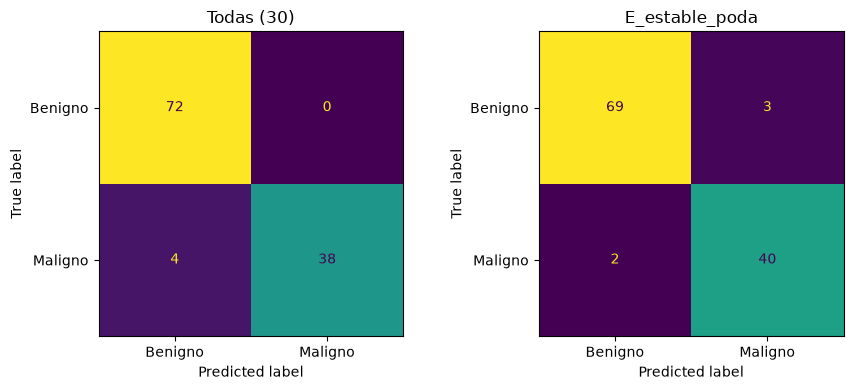

                        n_vars  accuracy  precision  recall     F1    FN   FP
Todas (30)                30.0     0.965       1.00   0.905  0.950   4.0  0.0
E_estable_poda             8.0     0.956       0.93   0.952  0.941   2.0  3.0
Base (siempre benigno)     0.0     0.632       0.00   0.000  0.000  42.0  0.0
              precision    recall  f1-score   support

     Benigno       0.97      0.96      0.97        72
     Maligno       0.93      0.95      0.94        42

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

elegido = "E_estable_poda"
selected_features = candidatos[elegido]
print(elegido, selected_features)

final = {}
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (nombre, vs) in zip(axes, {"Todas (30)": list(X.columns), elegido: selected_features}.items()):
    m = make_rna(SEED).fit(X_dev[vs], y_dev)
    final[nombre] = {"n_vars": len(vs), **metricas(m, X_test[vs], y_test)}
    ConfusionMatrixDisplay.from_estimator(m, X_test[vs], y_test,
                                          display_labels=["Benigno", "Maligno"],
                                          ax=ax, colorbar=False)
    ax.set_title(nombre)
plt.tight_layout(); plt.show()

base = DummyClassifier(strategy="most_frequent").fit(X_dev, y_dev)
final["Base (siempre benigno)"] = {"n_vars": 0, **metricas(base, X_test, y_test)}

print(pd.DataFrame(final).T.round(3).to_string())

m_final = make_rna(SEED).fit(X_dev[selected_features], y_dev)
print(classification_report(y_test, m_final.predict(X_test[selected_features]),
                            target_names=["Benigno", "Maligno"]))

## 10. Discusión y conclusión

> Uso exclusivamente educativo. Los resultados no constituyen una herramienta clínica.

### 10.1 Datos y partición

- Dataset: Breast Cancer Wisconsin (Diagnostic), 569 casos y 30 variables numéricas (10 medidas × 3 resúmenes: media, error estándar y peor valor), sin valores nulos. El identificador no entra como variable. Clases: 357 benignos (63 %) y 212 malignos (37 %).
- Partición estratificada 60/20/20 con semilla 42: entrenamiento 341 casos (37,2 % malignos), validación 114 (37,7 %) y prueba 114 (36,8 %). Todas las comparaciones usan la misma partición.
- Las escalas difieren en más de cinco órdenes de magnitud (por ejemplo, `area3` tiene media 880 y `fractal_dimension2` 0,004), por lo que se estandariza dentro de un `Pipeline`, ajustando el escalado solo con los datos de entrenamiento.

### 10.2 Redundancia

- Hay 21 pares con |r| > 0.9. Radio, perímetro y área forman un único bloque de "tamaño": las correlaciones son de 0,986 a 0,998 entre las medidas de la media, de 0,977 a 0,994 entre las del peor valor y de 0,923 a 0,970 entre las del error estándar. Además hay correlaciones de 0,97 entre los sufijos 1 y 3 (por ejemplo, `radius1` con `radius3` 0,975), de modo que las seis columnas de tamaño equivalen en la práctica a una sola variable.
- Un segundo bloque, más pequeño, agrupa concavidad y puntos cóncavos (`concavity1`-`concave_points1` 0,924; `concave_points1`-`concave_points3` 0,915).
- El umbral de 0,9 es una decisión de diseño, no un hecho: otro corte daría otro número de pares.
- **Textura:** `texture1` y `texture3` tienen r = 0,910 entre sí, por encima del umbral de 0,9, así que son casi redundantes: alcanza con una de las dos. `texture2` (error estándar) correlaciona poco con ellas (0,373 con `texture1` y 0,399 con `texture3`). La textura tampoco es redundante con el tamaño: sus mayores correlaciones con variables de otras medidas son 0,357 (`texture1` con `perimeter3`), 0,365 (`texture3` con `perimeter3`) y 0,420 (`texture2` con `symmetry2`). Esto es coherente con 10.4: la señal de textura la aporta `texture3`, que además es más informativa por sí sola (F de ANOVA 104,5 contra 77,5 de `texture1`); con r = 0,910 la elección entre ambas es en parte intercambiable.
- **Resúmenes de cada medida:** la correlación entre la media (resumen 1) y el peor valor (resumen 3) es alta en todas las medidas (0,705 a 0,976) y supera 0,9 en cinco: radio, textura, perímetro, área y puntos cóncavos. El error estándar (resumen 2) es el menos redundante: su correlación con la media va de 0,332 a 0,810 y con el peor valor de 0,305 a 0,851, con los valores más bajos en suavidad (0,332 y 0,305) y textura (0,373 y 0,399). Que sea poco redundante no implica que sea relevante: `texture2`, `smoothness2` y `symmetry2` tienen F menor que 1 en ANOVA.

### 10.3 Relevancia por técnica

- **ANOVA e información mutua** coinciden en las mismas ocho variables más relevantes (`concave_points3`, `perimeter3`, `concave_points1`, `radius3`, `perimeter1`, `radius1`, `area3`, `area1`), pero seis de ellas pertenecen al bloque de tamaño, por lo que un ranking de este tipo sin más repetiría información. Las variables sin relevancia individual (F menor que 3 e información mutua cercana a cero) son `texture2`, `symmetry2`, `fractal_dimension1`, `smoothness2` y `fractal_dimension2`.
- **Regresión logística con L1:** la cantidad de variables con coeficiente distinto de cero crece de forma gradual con `C` (5, 6, 7, 9 y 14 variables con C = 0,05, 0,1, 0,2, 0,5 y 1,0), sin un codo claro. Se usó C = 0,2 (7 variables), elección propia y no un valor óptimo. De las seis columnas de tamaño solo conservó `radius3` y `area3`, y seleccionó `concave_points1`, `texture3`, `symmetry3` y `smoothness3`.
- **RFE** (10 variables) retuvo cinco variables del bloque de tamaño (`radius1`, `radius2`, `radius3`, `perimeter3`, `area3`): con variables casi duplicadas, la eliminación recursiva reparte los coeficientes de forma casi arbitraria y no las trata como redundantes.
- **Importancia por permutación** (red con las 30 variables, calculada sobre validación): los valores son muy pequeños (máximo 0,0225) y, con 114 casos de validación, un solo caso mueve el F1 en torno a 0,01, por lo que gran parte del ranking no se distingue del ruido. Siete variables dieron valores nulos o negativos. Esta técnica subestima a variables que tienen copias (como `concave_points1`, casi nula pese a su relevancia en las demás técnicas).
- Las técnicas no coinciden entre sí: ANOVA y la información mutua privilegian al bloque de tamaño, mientras que L1, RFE y la permutación seleccionan variables de otros grupos (`texture3`, `smoothness3`, `symmetry3`). Esto justifica combinarlas.

### 10.4 Estabilidad (50 remuestreos bootstrap del entrenamiento)

- Las variables más estables son `concave_points1` (0,99 de selección media entre las tres técnicas) y `radius3` (0,94). `texture3` fue elegida por L1 y RFE en el 100 % de los remuestreos, y es la señal más consistente entre las variables que no son de tamaño. Su valor 0,00 en ANOVA se debe a que ese ranking solo conserva 10 variables y siempre las ocupa el bloque de tamaño y concavidad.
- `smoothness3` (L1 0,78; RFE 0,56) y `symmetry3` (L1 0,98; RFE 0,28) aportan información distinta del tamaño, con menor acuerdo entre técnicas.
- Dentro del bloque de tamaño, la elección entre `radius3`, `area3` y `perimeter3` es inestable entre técnicas (por ejemplo, `perimeter3` pasa de 0,32 en L1 a 0,84 en RFE), lo esperable con variables casi idénticas.
- `fractal_dimension2` había aparecido en RFE y en la permutación pese a su baja relevancia individual, y se planteó la hipótesis de un efecto "supresor". La estabilidad no la respalda: 0,32 en L1, 0,34 en RFE y 0,00 en ANOVA. Su importancia en la permutación es probablemente ruido de una sola red con 114 casos de validación.
- `texture1` tuvo estabilidad de 0,04: la señal de textura la aporta `texture3`, no `texture1`.

### 10.5 Subconjuntos candidatos y comparación en validación

A los rankings de ANOVA, información mutua y estabilidad (A, B y E) se les aplicó una poda de redundancia (se descarta toda variable con |r| > 0,9 respecto de una ya elegida); RFE, L1 y permutación (C, D y F) se usaron sin poda. Todos los conjuntos se compararon con la misma red (capas de 32 y 16, ReLU) y la misma partición.

| Conjunto | Vars | Accuracy | Recall | F1 | FN | FP | F1 (5 semillas) | FN medio (5 sem.) |
|---|---|---|---|---|---|---|---|---|
| Todas | 30 | 0,965 | 0,977 | 0,955 | 1 | 3 | 0,966 ± 0,011 | 1,0 |
| A ANOVA + poda | 10 | 0,974 | 0,977 | 0,966 | 1 | 2 | 0,977 ± 0,008 | 0,6 |
| B información mutua + poda | 10 | 0,965 | 0,977 | 0,955 | 1 | 3 | 0,955 ± 0,008 | 1,0 |
| C RFE | 10 | 0,939 | 0,953 | 0,921 | 2 | 5 | 0,933 ± 0,008 | 1,4 |
| D L1 | 7 | 0,956 | 0,953 | 0,943 | 2 | 3 | 0,943 ± 0,000 | 2,0 |
| E estabilidad + poda | 8 | 0,965 | 0,977 | 0,955 | 1 | 3 | 0,961 ± 0,006 | 1,0 |
| F permutación | 10 | 0,974 | 0,977 | 0,966 | 1 | 2 | 0,970 ± 0,010 | 1,0 |

- Con 8 a 10 variables, A, B, E y F igualan el desempeño de las 30 variables (A y F cometen 3 errores en validación, y B y E 4, contra 4 de "Todas"). C y D tuvieron peor resultado, con 2 falsos negativos cada uno, y D mantuvo 2 falsos negativos en las 5 semillas. C, D y F no podan redundancia, pero F quedó entre los mejores, así que la poda no explica por sí sola la diferencia; una explicación posible, no probada, es que C y D se apoyan en coeficientes de una regresión logística lineal.
- Las diferencias entre A, B, E, F y "Todas" son de a lo sumo un caso en validación (3 o 4 errores contra 4) y del mismo orden que el desvío entre semillas (0,006 a 0,011 de F1), por lo que no permiten afirmar que un conjunto sea mejor que otro. Sí permiten afirmar que ninguno es peor que usar todas las variables.
- La poda depende del orden: en el conjunto A eliminó `concave_points1` (la variable más estable) por su correlación de 0,915 con `concave_points3`, que entró antes. Además, A incluye variables de estabilidad casi nula (`compactness1`, `compactness3`, `concave_points2`).
- F incluye `texture1` y `texture3` a la vez (r = 0,910) y varias medidas de tamaño casi duplicadas (`radius2`, `perimeter2`, `area2`, `perimeter3`, `area3`), información redundante que la poda de A, B y E evita.


### 10.6 Selección final y justificación

Se elige el conjunto **E (estabilidad + poda)**, con 8 variables: `concave_points1`, `radius3`, `texture3`, `smoothness3`, `symmetry3`, `radius2`, `concavity3` y `fractal_dimension2`.

- **Desempeño:** iguala a "Todas" en validación (accuracy 0,965; recall 0,977; 1 falso negativo).
- **Estabilidad:** sus variables salen de la tabla de remuestreo (`concave_points1`, `radius3`, `texture3`, `smoothness3`, `symmetry3`), y tiene un desvío bajo entre semillas (0,006); solo D tiene menos (0,000), pero porque obtuvo el mismo F1 y 2 falsos negativos en cada una de las 5 semillas (más estable, pero con peor desempeño)
- **Cantidad de variables:** 8 en lugar de 30.
- Quedan tres variables débiles: `radius2`, `concavity3` y `fractal_dimension2` (esta última con estabilidad de 0,22) entraron para completar la lista, no por mérito propio.
- El conjunto A tuvo un F1 medio algo mayor, pero la diferencia no se distingue del ruido y se prefirió E por estabilidad y por tener menos variables. A es una alternativa defendible.

### 10.7 Resultados en prueba (una sola evaluación)

Configuración congelada; se reentrenó con entrenamiento y validación (455 casos) y se evaluó una sola vez sobre los 114 casos de prueba.

| Modelo | Vars | Accuracy | Precisión | Recall | F1 | FN | FP |
|---|---|---|---|---|---|---|---|
| RNA con las 30 variables | 30 | 0,965 | 1,000 | 0,905 | 0,950 | 4 | 0 |
| RNA con subconjunto E | 8 | 0,956 | 0,930 | 0,952 | 0,941 | 2 | 3 |
| Línea base (siempre benigno) | 0 | 0,632 | 0,000 | 0,000 | 0,000 | 42 | 0 |

- E detectó 40 de los 42 casos malignos y "Todas" detectó 38: E tiene dos falsos negativos menos, a cambio de tres falsos positivos (la red con 30 variables no tuvo ninguno).
- En accuracy y F1, "Todas" queda ligeramente por encima (diferencia de un paciente), que no es concluyente.
- En un contexto diagnóstico un caso maligno no detectado es más grave que un benigno clasificado como maligno, por lo que el menor número de falsos negativos de E es el resultado más relevante.
- Ambas redes superan ampliamente a la línea base (accuracy 0,632).

### 10.8 Prevención de fugas de información

- El identificador se excluyó.
- Los rankings de ANOVA, información mutua, L1, RFE y el análisis de estabilidad se calcularon solo con entrenamiento (con escalado ajustado solo en entrenamiento). La importancia por permutación se evaluó sobre validación, no sobre prueba.
- El escalado de las redes está dentro del `Pipeline`.
- La comparación de candidatos y la elección del conjunto final se hicieron sobre validación, lo que introduce un pequeño sesgo de selección en las métricas de validación. La prueba se usó una sola vez, con la configuración ya congelada.
- La importancia por permutación (candidato F) se calculó sobre validación, y luego F se comparó en esa misma validación, por lo que sus métricas de validación están algo infladas respecto de los otros candidatos. No afecta a la prueba, que no participó en ninguna decisión.
- La comparación de validación entrena solo con entrenamiento, pero para la prueba se reentrenó con entrenamiento + validación. El cambio se aplicó igual a "Todas" y a E, por lo que la comparación entre ambos sigue siendo válida.

### 10.9 Limitaciones

- Dataset pequeño (569 casos): en validación y en prueba un solo paciente mueve el accuracy menos de un punto y el recall unos 2 puntos. Las diferencias de uno o dos casos entre conjuntos no son concluyentes.
- Una sola partición y, en la prueba, una sola semilla. En validación el desvío entre semillas es del mismo orden que las diferencias entre conjuntos.
- La poda por correlación depende del orden de los rankings y el umbral (0,9) y los tamaños de cada conjunto son decisiones de diseño. El valor C = 0,2 de L1 también es una elección propia.
- La importancia por permutación es ruidosa y subestima variables con copias; el promedio de estabilidad mezcla técnicas con criterios distintos.
- Uso exclusivamente educativo: los resultados no constituyen una herramienta clínica.

### 10.10 Conclusión

Con 8 variables (conjunto E) se alcanza un desempeño comparable al de las 30 variables: en validación coincide con "Todas" y en prueba detecta dos casos malignos más (40 de 42 contra 38 de 42), a costa de tres falsos positivos y un accuracy apenas inferior (0,956 contra 0,965). La redundancia de las medidas de tamaño (radio, perímetro y área) es tan alta que alcanza con una sola de ellas, y las variables más consistentes entre técnicas son `concave_points1`, `radius3` y `texture3`. Las diferencias entre A, B, E y F son de a lo sumo un paciente en validación y no permiten declarar un ganador. Lo que sí muestran es que reducir de 30 a 8 variables no empeoró la detección de malignos y simplificó el modelo, y que RFE y L1 fueron los peores, sin que la poda de redundancia alcance a explicarlo (F tampoco la usó y quedó entre los mejores).